# Constant-gain learning: Monte Carlo check of the stationary distribution of $\beta_t$

This notebook simulates the constant-gain (geometrically-weighted) WLS learning rule and checks whether the simulated stationary distribution of $\beta_t$ matches the theoretical Gaussian approximation:

$$\beta_t \approx \mathcal N\left(0,\; \gamma\,\frac{s_d^2(1-\kappa)}{2\sigma_x^2}\right).$$

## Notes on timing
To avoid an implicit dependence of returns on $\beta_{t+1}$ (which would make simulation circular), we use a one-step lag in the pricing term:

$$r_{t+1}=\log(\varepsilon^d_{t+1}) + g_{\beta_{t-1}}(x_{t-1})-g_{\beta_t}(x_t),$$

and then update $(M_{t+1},\beta_{t+1})$ using $(x_t,r_{t+1})$. This is consistent with an information structure where $\beta_t$ is based on data up to $t-1$.

For small $\gamma$, this timing choice does not affect the Gaussian approximation around $\beta^*=0$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log

rng = np.random.default_rng(123)

def g(beta, x, kappa, w):
    """g_beta(x) = log(1 - kappa * exp(w * tanh(x*beta/w)))"""
    return np.log(1.0 - kappa * np.exp(w * np.tanh((x * beta) / w)))

def simulate_path(T, burn, gamma, sigma_x, s_d, kappa, eps=1e-6, beta0=0.0, M0=None, seed=None):
    """Simulate one path and return beta series after burn-in.

    Parameters
    ----------
    T : int
        Total simulation length.
    burn : int
        Burn-in length.
    gamma : float
        Constant gain.
    sigma_x : float
        Std dev of x_t.
    s_d : float
        Std dev of log dividend shock (log eps^d).
    kappa : float
        kappa = delta a^{-gamma} phi.
    eps : float
        Small slack used to define w = -log(kappa) - eps.
    """
    if seed is None:
        local_rng = rng
    else:
        local_rng = np.random.default_rng(seed)

    # boundedness parameter
    w = -np.log(kappa) - eps
    if w <= 0:
        raise ValueError("Need w>0, which requires kappa in (0,1) and eps small enough.")

    # shocks
    x = local_rng.normal(0.0, sigma_x, size=T+1)
    # log eps^d ~ N(-s_d^2/2, s_d^2)
    log_eps_d = local_rng.normal(-0.5*s_d**2, s_d, size=T+1)

    beta = np.zeros(T+1)
    M = np.zeros(T+1)
    r = np.zeros(T+1)

    beta[0] = beta0
    if M0 is None:
        M[0] = sigma_x**2
    else:
        M[0] = float(M0)

    # define beta_{-1} and x_{-1} for t=0 convenience
    beta_lag = beta0
    x_lag = 0.0

    for t in range(T):
        # return realization (timing avoids dependence on beta_{t+1})
        r[t+1] = log_eps_d[t+1] + g(beta_lag, x_lag, kappa, w) - g(beta[t], x[t], kappa, w)

        # update second moment with constant gain
        M[t+1] = M[t] + gamma * (x[t]**2 - M[t])
        # numerical guard
        if M[t+1] <= 1e-12:
            M[t+1] = 1e-12

        # update beta using (x_t, r_{t+1})
        beta[t+1] = beta[t] + gamma * (x[t] / M[t+1]) * (r[t+1] - x[t] * beta[t])

        # shift lags
        beta_lag = beta[t]
        x_lag = x[t]

    return beta[burn+1:], beta, M, r

def theoretical_var(gamma, sigma_x, s_d, kappa):
    return gamma * s_d**2 * (1.0 - kappa) / (2.0 * sigma_x**2)


In [2]:
# --- Parameters (edit as desired) ---
gamma = 0.02        # constant gain
sigma_x = 0.01       # std dev of predictor
s_d = 0.01          # std dev of log eps^d
kappa = 0.8         # must be in (0,1)
eps = 1e-4          # slack in w = -log(kappa) - eps

# simulation controls
T = 50_000          # length per path
burn = 10_000       # burn-in per path
N = 200             # number of Monte Carlo paths

var_th = theoretical_var(gamma, sigma_x, s_d, kappa)
sd_th = np.sqrt(var_th)

print("Theoretical approx: beta ~ N(0, var)")
print("var_th =", var_th)
print("sd_th  =", sd_th)


Theoretical approx: beta ~ N(0, var)
var_th = 0.0019999999999999996
sd_th  = 0.04472135954999579


In [3]:
# Monte Carlo: collect beta draws from the post-burn-in segment
betas = []
for n in range(N):
    beta_draws, *_ = simulate_path(T=T, burn=burn, gamma=gamma, sigma_x=sigma_x, s_d=s_d, kappa=kappa, eps=eps, seed=10_000+n)
    # subsample to reduce dependence (optional)
    betas.append(beta_draws[::10])

betas = np.concatenate(betas)
print("Total beta draws:", betas.size)
print("Sample mean:", betas.mean())
print("Sample var :", betas.var(ddof=1))


Total beta draws: 800000
Sample mean: -19.506627686345883
Sample var : 107018.00040126774


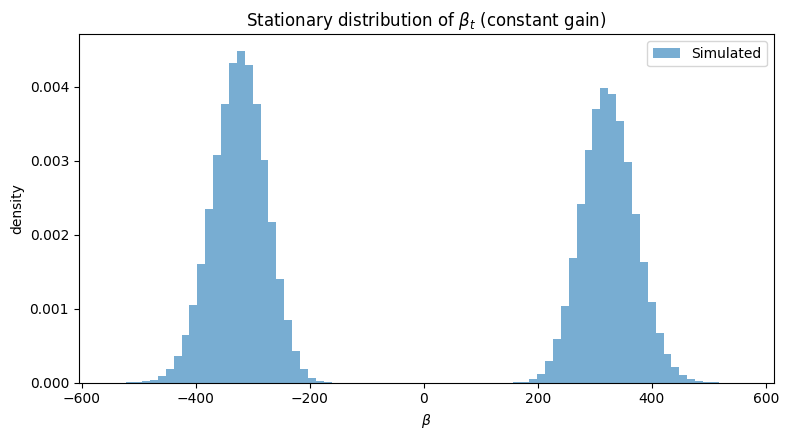

In [4]:
# Visual check: histogram vs theoretical normal pdf
xs = np.linspace(betas.min(), betas.max(), 400)
pdf_th = (1.0/(sd_th*np.sqrt(2*np.pi))) * np.exp(-0.5*(xs/sd_th)**2)

plt.figure(figsize=(8,4.5))
plt.hist(betas, bins=80, density=True, alpha=0.6, label='Simulated')
#plt.plot(xs, pdf_th, linewidth=2, label='Theoretical N(0,var)')
plt.title('Stationary distribution of $\\beta_t$ (constant gain)')
plt.xlabel(r'$\beta$')
plt.ylabel('density')
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
# Formal-ish diagnostics: mean/variance z-scores + KS test (optional)
from scipy import stats

# z-score of mean under N(0,var_th) treating draws as iid (optimistic)
se_mean = sd_th / np.sqrt(betas.size)
z_mean = betas.mean() / se_mean

# compare variance via ratio
var_hat = betas.var(ddof=1)
ratio = var_hat / var_th

# KS test against N(0, sd_th)
ks = stats.kstest(betas, 'norm', args=(0.0, sd_th))

print(f"Mean z-score (iid approx): {z_mean:.3f}")
print(f"Variance ratio var_hat/var_th: {ratio:.3f}")
print("KS statistic:", ks.statistic)
print("KS p-value  :", ks.pvalue)


Mean z-score (iid approx): -3890814.313
Variance ratio var_hat/var_th: 5350878182.292
KS statistic: 0.53
KS p-value  : 0.0


## What to expect

- The match improves as $\gamma$ gets smaller.
- If you increase $\kappa$ closer to 1, the theoretical variance shrinks (because $(1-\kappa)$ becomes small) and the algorithm becomes more tightly mean-reverting.
- If you set $\gamma$ too large, the stationary distribution becomes noticeably non-Gaussian and the variance formula can be off.

### Robustness checks

1. Try multiple values of $\gamma$ (e.g. 0.01, 0.02, 0.05) and see how the fit changes.
2. Increase the subsampling gap (e.g. `[::50]`) to reduce serial dependence.
3. Increase $T$ and $N$ if you want tighter Monte Carlo error.
